# Screening fixes for model-agreement false alarms (iteration-5 FREEZE, Part A demo)

**Setting.** Natural-language to first-order logic (NL→FOL) outputs are scored **without a gold formula**. The incumbent
metric **V0 = `c_score_align`** checks a candidate formula against translations of the same sentence produced by
*other model families*. It returns **1 − (share of other-family peers that are logically equivalent to the candidate)**.
Equivalence is decided by z3, either exactly or after aligning predicate vocabularies (the "eqmv" pairwise matrix).
Higher score = more likely ERROR.

V0's main failure is **false alarms (`d`)**: a correct candidate gets flagged because its peers disagree with it,
typically because they use a different vocabulary or granularity. This experiment asks whether five **label-free
rescorings** of the same pairwise matrix fix that without raising **error endorsement (`e`)**, i.e. errors that pass unflagged:

| variant | idea |
|---|---|
| V1 | plurality-normalised: compare the candidate's support with the largest peer class |
| V2 | reliability-weighted: weight each peer family by its label-free, out-of-fold cross-family agreement rate |
| V3 | V1 + V2 |
| V4 | cross-fitted logistic blend of `c_exact` (aligner-free) and `c_align` (= V0) |
| V5 | V3 on a cheaper 3-family peer pool |

A **pre-registered rule** decides whether any variant replaces V0: the long-sentence stratified AUROC must improve by
≥ +0.015, the L25 stratum must not get worse, and the control stratum may lose at most 0.01.
On the full development set (2,672 labelled rows, 283 sentences) the rule chose **"NONE: V0 stands"**.

**What this notebook does.** The original `method.py` is an orchestrator: it runs ~25 `src/` scripts in a fixed order.
Those scripts need the whole run's input tree, so the notebook keeps the orchestrator's step table and loop as a
*dry run*. It then runs the core Part-A pipeline inline, on a **93-row / 12-sentence subset** (whole sentences, all four
strata). Every function comes from the artifact's own files with no edits (`freeze/consensus_variants.py`, `src/stats.py`,
`src/labels.py`, `src/screen.py`, `src/select_rule.py`):

1. label-free scoring of V0_rep, c_exact and V1–V5 from the pairwise matrix, plus a reproduction check against the sealed scores;
2. the label join and AUROC screen with sentence-cluster bootstrap CIs, paired Δ vs V0, and the e/d decomposition;
3. the pre-registered selection rule, its stability, and a permutation null;
4. gate g3 for the gloss-gated agreement metric GG (GG vs V0);
5. a comparison with the full-run numbers.

Numbers on 93 rows are **illustrative only**. The subset is far too small to support the full-run conclusions, so each
plot shows the full-run reference next to the demo value.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install (method.py logs through it)
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- method.py imports (original)
from __future__ import annotations

import argparse
import os
import subprocess
import sys
import time
from pathlib import Path

from loguru import logger

# --- imports of the src/ + freeze/ modules run inline below (stats.py, labels.py, screen.py, select_rule.py, consensus_variants.py)
import json
import math
from collections import Counter, defaultdict
from typing import Sequence

import numpy as np
import pandas as pd
from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression

# --- notebook-only: visualisation
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/main/round-5/experiment-14/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["source"])
print("rows:", data["metadata"]["n_rows"], "| sentences:", data["metadata"]["n_sentences"],
      "| matrix records:", len(data["pairwise_matrix"]))
print(pd.Series([r["stratum"] for r in data["rows"]]).value_counts().to_dict(),
      pd.Series([r["label"] for r in data["rows"]]).value_counts().to_dict())
ex = data["rows"][0]
print("\nexample row:", {k: ex[k] for k in ("text", "candidate_fol", "system", "label", "V0_frozen", "V1", "V4")})

iteration-5 FREEZE experiment (art_EU1yuNrRl4od), dataset E held-out rows, population Z
rows: 93 | sentences: 12 | matrix records: 12
{'CTRL': 24, 'EXC': 24, 'L25': 23, 'L20': 22} {'ERROR': 54, 'CORRECT': 39}

example row: {'text': 'A vehicle that is designed for off-road use, has four-wheel drive, and is built for rugged terrain is either a jeep or a pickup truck.', 'candidate_fol': '∀x ((DesignedForOffRoad(x) ∧ FourWheelDrive(x) ∧ BuiltForRuggedTerrain(x)) → (Jeep(x) ∨ PickupTruck(x)))', 'system': 'G1:meta-llama/llama-3.1-8b-instruct', 'label': 'ERROR', 'V0_frozen': 0.75, 'V1': 0.0, 'V4': 0.6081737363673899}


## Config

The bootstrap and resampling sizes are the only tunable parameters. The constants below them are copied from
`src/common.py` and `src/select_rule.py` and are **pre-registered**; do not tune them.
Original full-run values: `B = 2000` (sentence-cluster bootstrap), `B_STAB = 500` (selection-stability resamples),
`B_NULL = 200` (label permutations).

In [5]:
# ---- tunable (demo values; originals in comments)
B = 2000          # sentence-cluster bootstrap replicates (original: 2000)
B_STAB = 500     # within-stratum resamples for selection stability (original: 500)
B_NULL = 200     # within-stratum label permutations for the null (original: 200)
RUN_SCRIPTS = False  # method.py would subprocess each src/ script; they are not shipped here, so the loop is a dry run

# ---- fixed / pre-registered (src/common.py)
STRATA = ("L25", "L20", "EXC", "CTRL")
LONG = ("L25", "L20", "EXC")
NEUTRAL_C = 0.6266243516243516  # exp-5 prereg imputation.neutral.c_score_align (|P| < 2 rows)
SEED = 20260924

## 1. The orchestrator (`method.py`)

`STEPS` is the pre-registered execution order. Each entry holds a stage, a script with its arguments, a working
directory, and a *marker* output. If the marker already exists the step is skipped, which makes re-runs idempotent and
free: every LLM verdict is cached, and frozen writers refuse to overwrite. The stages:

* **A**: Part A, the V0–V5 screen. Sections 2–5 below reproduce its core inline.
* **B**: Part B, GG (exact z3 equivalence, or an exhaustive injective symbol map plus a Gemini-2.5-flash gloss check).
* **GGB**: secondary bridge search.
* **C**: vendored library.
* **OUT**: output files.
* **TEST**: pytest, audit and smoke checks.

The code is unchanged except for two things. The file log sink is commented out. `subprocess.run` is guarded by
`RUN_SCRIPTS`, so the loop only prints the plan.

In [6]:
ROOT = Path.cwd()  # original: Path(__file__).resolve().parent
SRC = ROOT / "src"
PY = sys.executable

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
# (ROOT / "logs").mkdir(exist_ok=True)
# logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")

# (stage, script + args, cwd, output that marks the step done)
STEPS = [
    ("A", ["copy_inputs.py"], SRC, "inputs_manifest.json"),
    ("A", ["step0_gates.py"], SRC, "results/gate_G0.json"),
    ("A", ["prereg_improve.py"], SRC, "prereg_improve.json"),
    ("A", ["make_row_index.py"], SRC, "results/row_index_labelfree.jsonl"),
    ("A", ["score_variants.py"], SRC, "results/scores_E_variants.jsonl"),
    ("A", ["fit_v4.py"], SRC, "results/scores_E_V4.jsonl"),
    ("A", ["screen.py"], SRC, "results/screen_E.json"),
    ("A", ["select_rule.py"], SRC, "results/selection_E.json"),
    ("A", ["freeze_part_a.py"], SRC, "freeze/selection.json"),
    ("B", ["probe.py"], SRC, "results/probe.json"),
    ("B", ["prereg_gg.py"], SRC, "prereg_gg.json"),
    ("B", ["gg_search.py", "all"], SRC, "results/gg_search.jsonl"),
    ("B", ["gg_gates.py", "dev", "v1"], SRC, "results/gg_gates_dev_v1.json"),
    ("B", ["gg_gates.py", "confirm", "v2"], SRC, "results/gg_gates_confirm_v2.json"),
    ("B", ["gg_gloss.py"], SRC, "results/gg_verdicts.json"),
    ("B", ["gg_score.py"], SRC, "results/gg_dev.json"),
    ("B", ["freeze_part_b.py"], SRC, "freeze/gg_gate.json"),
    ("GGB", ["ggb_search.py", "all"], SRC, "results/ggb_search.jsonl"),
    ("GGB", ["ggb_score.py"], SRC, "results/ggb_dev.json"),
    ("C", ["vendor_lib.py"], SRC, "lib/PROVENANCE.json"),
    ("OUT", ["make_outputs.py"], SRC, "method_out.json"),
    ("OUT", ["make_tables.py"], SRC, "tables.md"),
    ("TEST", ["-m", "pytest", "-q", "tests/test_variants.py", "tests/test_gg.py", "tests/test_budget.py"], ROOT, None),
    ("TEST", ["tests/audit_rederive.py"], ROOT, None),
    ("TEST", ["tests/smoke_lib.py"], ROOT, None),
]
NEVER_FORCE = {"prereg_improve.py", "prereg_gg.py", "freeze_part_a.py"}  # immutable writers


@logger.catch(reraise=True)
def main(argv=None):
    ap = argparse.ArgumentParser()
    ap.add_argument("--stage", default="A,B,GGB,C,OUT,TEST")
    ap.add_argument("--force", action="store_true")
    a = ap.parse_args(argv)  # notebook: explicit argv instead of sys.argv
    stages = set(a.stage.split(","))
    env = {**os.environ, "PYTHONHASHSEED": "0"}
    for stage, args, cwd, marker in STEPS:
        if stage not in stages:
            continue
        name = args[0]
        if marker and (ROOT / marker).exists() and (not a.force or name in NEVER_FORCE):
            logger.info(f"[{stage}] skip {' '.join(args)} ({marker} exists)")
            continue
        logger.info(f"[{stage}] run {' '.join(args)}")
        if not RUN_SCRIPTS:  # notebook: dry run (src/ scripts and the run's input tree are not shipped)
            continue
        t0 = time.time()
        try:
            subprocess.run([PY, *args], cwd=cwd, env=env, check=True)
        except subprocess.CalledProcessError as e:
            logger.error(f"[{stage}] {name} failed with exit code {e.returncode}")
            raise
        logger.info(f"[{stage}] {name} done in {time.time() - t0:.0f}s")


main(["--stage", "A,B,GGB,C,OUT,TEST"])
print("(dry run: RUN_SCRIPTS = False, no src/ script was executed; sections 2-7 reproduce the core of stage A + GG gate g3 inline)")

19:40:37|INFO   |[A] run copy_inputs.py


19:40:37|INFO   |[A] run step0_gates.py


19:40:37|INFO   |[A] run prereg_improve.py


19:40:37|INFO   |[A] run make_row_index.py


19:40:37|INFO   |[A] run score_variants.py


...

19:40:37|INFO   |[OUT] run make_tables.py


19:40:37|INFO   |[TEST] run -m pytest -q tests/test_variants.py tests/test_gg.py tests/test_budget.py


19:40:37|INFO   |[TEST] run tests/audit_rederive.py


19:40:37|INFO   |[TEST] run tests/smoke_lib.py


(dry run: RUN_SCRIPTS = False, no src/ script was executed; sections 2-7 reproduce the core of stage A + GG gate g3 inline)


## 2. The frozen label-free scorers (`freeze/consensus_variants.py`, verbatim)

Every scorer reads a single sentence's record from eval-2's **pairwise matrix**:
* `nodes`: the distinct canonical FOL formulas and the candidate rows that produced them;
* `pairs`: z3 verdicts `[i, j, eq, kind]`, with `kind` ∈ {exact, align, gran};
* `cliques`: greedy equivalence classes.

The peer pool is *leave-own-family-out*: parseable peer rows from other model families, excluding the candidate itself.
No gold formula and no label is read anywhere in this cell. Scores are oriented so that **higher = more likely ERROR**.

In [7]:
POOL3 = ("deepseek", "microsoft", "openai")
SHRINK = 20.0


# ------------------------------------------------------------------------------------------------ index
def build_index(rec: dict) -> dict:
    '''Index one pairwise_classes record. Returns {'sid', 'node_of', 'meta', 'eq', 'kind', 'clique_of'}.
    MEASURES: nothing (data structure). GOLD-FREE: yes. COST: O(#pairs).'''
    eq, kind = {}, {}
    for i, j, e, k, _s in rec["pairs"]:
        eq[(i, j)] = eq[(j, i)] = e
        kind[(i, j)] = kind[(j, i)] = k
    node_of, meta = {}, {}
    for nd in rec["nodes"]:
        for r in nd["rows"]:
            node_of[r["row_key"]] = nd["node_id"]
            meta[r["row_key"]] = r
    clique_of = {}
    for ci, cl in enumerate(rec.get("cliques") or [[nd["node_id"]] for nd in rec["nodes"]]):
        for n in cl:
            clique_of[n] = ci
    return {"sid": rec["sentence_id"], "node_of": node_of, "meta": meta, "eq": eq, "kind": kind, "clique_of": clique_of,
            "nodes": rec["nodes"]}


def agree(ix: dict, a: int, b: int) -> bool:
    '''eqmv agreement of two nodes (same node = True; UNKNOWN = False).'''
    return True if a == b else ix["eq"].get((a, b)) is True


def agree_exact(ix: dict, a: int, b: int) -> bool:
    '''Aligner-free agreement: same node, or eq True with kind 'exact'.'''
    return True if a == b else (ix["eq"].get((a, b)) is True and ix["kind"].get((a, b)) == "exact")


def peers_lofo(ix: dict, row_key: str, families: tuple | None = None, family_key: str = "family") -> list[str]:
    '''Peer rows of candidate `row_key`: is_peer, other vendor family, not itself; optionally restricted to `families`.
    MEASURES: the pool. GOLD-FREE: yes.'''
    fam = ix["meta"][row_key][family_key]
    out = []
    for rk, m in ix["meta"].items():
        if not m["is_peer"] or m[family_key] == fam or rk == row_key:
            continue
        if families is not None and m[family_key] not in families:
            continue
        out.append(rk)
    return sorted(out)


# ------------------------------------------------------------------------------------------------ V0 / exact
def c_score_align(ix: dict, row_key: str, peers: list[str] | None = None, min_peers: int = 2) -> float | None:
    '''V0 = 1 - share of peers eqmv-agreeing. REPRODUCTION ONLY (E2 must use exp-5 byte-identical code for V0).
    MEASURES: disagreement with other-family translations modulo vocabulary alignment. GOLD-FREE: yes.'''
    if row_key not in ix["node_of"]:
        return 1.0
    P = peers_lofo(ix, row_key) if peers is None else peers
    if len(P) < min_peers:
        return None
    c = ix["node_of"][row_key]
    return 1 - sum(agree(ix, c, ix["node_of"][p]) for p in P) / len(P)


def c_exact(ix: dict, row_key: str, peers: list[str] | None = None, min_peers: int = 2) -> float | None:
    '''1 - share of peers z3-equivalent with identical symbols (no aligner). GOLD-FREE: yes.'''
    if row_key not in ix["node_of"]:
        return 1.0
    P = peers_lofo(ix, row_key) if peers is None else peers
    if len(P) < min_peers:
        return None
    c = ix["node_of"][row_key]
    return 1 - sum(agree_exact(ix, c, ix["node_of"][p]) for p in P) / len(P)


# ------------------------------------------------------------------------------------------------ V1 / V3 / V5
def _pn(ix: dict, row_key: str, P: list[str], w: dict | None) -> float:
    c = ix["node_of"][row_key]
    wt = (lambda rk: 1.0) if w is None else (lambda rk: float(w.get(ix["meta"][rk]["family"], 1.0)))
    tot = sum(wt(p) for p in P)
    if tot <= 0:
        return 1.0
    share_a = sum(wt(p) for p in P if agree(ix, c, ix["node_of"][p])) / tot
    if share_a == 0:
        return 1.0
    cls = defaultdict(float)
    for p in P:
        cls[ix["clique_of"][ix["node_of"][p]]] += wt(p)
    max_share = max(cls.values()) / tot
    return 1 - min(1.0, share_a / max_share)


def c_pn(ix: dict, row_key: str, peers: list[str] | None = None, min_peers: int = 2) -> float | None:
    '''V1 plurality-normalised consensus: 1 - min(1, share_A / max_class_share) (share_A = 0 -> 1.0).
    MEASURES: how far the candidate's support falls short of the largest peer class (a candidate in the plurality of a
    scattered pool scores 0). GOLD-FREE: yes.'''
    if row_key not in ix["node_of"]:
        return 1.0
    P = peers_lofo(ix, row_key) if peers is None else peers
    if len(P) < min_peers:
        return None
    return _pn(ix, row_key, P, None)


def c_pn_rw(ix: dict, row_key: str, weights: dict, peers: list[str] | None = None, min_peers: int = 2) -> float | None:
    '''V3 = V1 with family-weighted shares. GOLD-FREE: yes (weights are label-free).'''
    if row_key not in ix["node_of"]:
        return 1.0
    P = peers_lofo(ix, row_key) if peers is None else peers
    if len(P) < min_peers:
        return None
    return _pn(ix, row_key, P, weights)


def c_v5(ix: dict, row_key: str, weights: dict, families: tuple = POOL3) -> float | None:
    '''V5 = V3 on the cost-matched 3-pool {deepseek, microsoft, openai} minus own family; >= 1 pool row required
    (eval-2 c_k3 convention: empty pool -> None, imputed neutral downstream). GOLD-FREE: yes.'''
    if row_key not in ix["node_of"]:
        return 1.0
    P = peers_lofo(ix, row_key, families=families)
    if len(P) < 1:
        return None
    return _pn(ix, row_key, P, weights)


# ------------------------------------------------------------------------------------------------ V2
def family_weights(indexes: list[dict], fold_of: dict, holdout_fold: int | None, shrink: float = SHRINK) -> dict:
    '''Label-free family reliability weights from the pairwise matrix of every sentence NOT in `holdout_fold`
    (holdout_fold None = all sentences). For family f and sentence s (>= 1 peer row of f and >= 1 peer row of another
    family): agr_f(s) = mean over (r in f, q not in f) of A(r, q). a_f = mean_s agr_f(s), n_f = #such sentences,
    abar = mean over all (f, s) of agr_f(s); w_f = (n_f * a_f + shrink * abar) / (n_f + shrink).
    MEASURES: how often a family's translations agree with other families' (a proxy for its reliability, Dawid-Skene
    style, no labels). GOLD-FREE: yes.'''
    per = defaultdict(list)
    allv = []
    for ix in indexes:
        if holdout_fold is not None and fold_of[ix["sid"]] == holdout_fold:
            continue
        peers = [rk for rk, m in ix["meta"].items() if m["is_peer"]]
        fams = defaultdict(list)
        for rk in peers:
            fams[ix["meta"][rk]["family"]].append(rk)
        for f, rs in fams.items():
            qs = [q for q in peers if ix["meta"][q]["family"] != f]
            if not rs or not qs:
                continue
            v = sum(agree(ix, ix["node_of"][r], ix["node_of"][q]) for r in rs for q in qs) / (len(rs) * len(qs))
            per[f].append(v)
            allv.append(v)
    abar = sum(allv) / len(allv) if allv else 0.0
    return {f: (len(v) * (sum(v) / len(v)) + shrink * abar) / (len(v) + shrink) for f, v in sorted(per.items())}


def c_rw(ix: dict, row_key: str, weights: dict, peers: list[str] | None = None, min_peers: int = 2) -> float | None:
    '''V2 = 1 - sum_{p in P agreeing} w_f(p) / sum_{p in P} w_f(p); families missing from `weights` get weight 1.0
    (never happens on E). GOLD-FREE: yes.'''
    if row_key not in ix["node_of"]:
        return 1.0
    P = peers_lofo(ix, row_key) if peers is None else peers
    if len(P) < min_peers:
        return None
    c = ix["node_of"][row_key]
    wt = {p: float(weights.get(ix["meta"][p]["family"], 1.0)) for p in P}
    tot = sum(wt.values())
    if tot <= 0:
        return 1.0
    return 1 - sum(wt[p] for p in P if agree(ix, c, ix["node_of"][p])) / tot


# ------------------------------------------------------------------------------------------------ V4
def c_two_channel(c_exact_v: float | None, c_align_v: float | None, coefs: dict) -> float | None:
    '''V4 = sigmoid(b0 + b_exact * c_exact + b_align * c_align). coefs = {'intercept', 'c_exact', 'c_align'}.
    MEASURES: a label-fitted blend of aligner-free and aligned disagreement. GOLD-FREE application (coefficients were fit
    on E labels, OOF in development).'''
    if c_exact_v is None or c_align_v is None:
        return None
    z = coefs["intercept"] + coefs["c_exact"] * c_exact_v + coefs["c_align"] * c_align_v
    return 1 / (1 + math.exp(-z))

### 2a. Score the candidates (`src/score_variants.py` loop, plus the V4 application from `fit_v4.py`)

This is the per-row loop of `score_variants.main()`. The only change is where the inputs come from: matrix records,
rows and weights are read from `data` instead of files. The V2 family weights are the **full run's out-of-fold weights**
(`per_fold_holdout[k]`, estimated on the ~560 sentences outside fold *k*). Re-estimating them on 12 sentences would not
reproduce the sealed scores. For the same reason V4 uses the per-fold cross-fitted coefficients from `results/v4_coefs.json`.
The cell then runs the **G1 check** used in the original run: the recomputed V0 must match the frozen exp-5 column to
1e-6 (that column is stored at 6-decimal precision).

In [8]:
IX = {r["sentence_id"]: build_index(r) for r in data["pairwise_matrix"]}
W = {int(k): v for k, v in data["family_weights"]["per_fold_holdout"].items()}
V4_FOLD_COEFS = {int(k): v for k, v in data["v4_coefs"]["per_fold"].items()}

scored = []
n_mis = n_cmp = 0
mism = []
for r in data["rows"]:
    rk, sid = r["row_key"], r["sentence_id"]
    ix = IX.get(sid)
    rec = {"row_key": rk, "sentence_id": sid, "fold": r["fold"], "stratum": r["stratum"], "family": r["family"],
           "V0_frozen": r["V0_frozen"]}
    in_mx = ix is not None and rk in ix["node_of"]
    rec["in_matrix"] = in_mx
    if not in_mx:
        rec.update(V0_rep=1.0, c_exact=1.0, V1=1.0, V2=1.0, V3=1.0, V5=1.0, c3_plain=1.0, n_peers=0, n_peers_3pool=0,
                   coverage_status="UNPARSEABLE")
    else:
        P = peers_lofo(ix, rk)
        P3 = peers_lofo(ix, rk, families=POOL3)
        w = W[r["fold"]]
        rec.update(n_peers=len(P), n_peers_3pool=len(P3), coverage_status="OK" if len(P) >= 2 else "PEER_UNAVAILABLE",
                   V0_rep=c_score_align(ix, rk, P), c_exact=c_exact(ix, rk, P), V1=c_pn(ix, rk, P),
                   V2=c_rw(ix, rk, w, P), V3=c_pn_rw(ix, rk, w, P), V5=c_v5(ix, rk, w),
                   c3_plain=(c_score_align(ix, rk, P3, min_peers=1)))
        rec["V5_imputed"] = rec["V5"] is None
        if rec["V5"] is None:
            rec["V5"] = NEUTRAL_C
        if rec["c3_plain"] is None:
            rec["c3_plain"] = NEUTRAL_C
    # V4 (fit_v4.py): cross-fitted logistic on (c_exact, c_align = V0_frozen) -- coefficients of the model that did NOT see this fold
    rec["V4"] = c_two_channel(rec["c_exact"], rec["V0_frozen"], V4_FOLD_COEFS[r["fold"]])
    if rec["V0_rep"] is not None and rec["V0_frozen"] is not None:
        n_cmp += 1
        if abs(rec["V0_rep"] - rec["V0_frozen"]) > 1e-6:  # per_item_T1 stores 6 decimals
            n_mis += 1
            mism.append({"row_key": rk, "rep": rec["V0_rep"], "frozen": rec["V0_frozen"], "n_peers": rec["n_peers"]})
    scored.append(rec)

print(f"G1 label-free part: {n_mis}/{n_cmp} = {n_mis / n_cmp:.4%} mismatch -> pass={n_mis / n_cmp <= 0.005}  (full run: 24/8,469 = 0.28%)")
# reproduction of the sealed per-row scores shipped in the mini data (full run's results/scores_E_variants.jsonl + scores_E_V4.jsonl)
for col in ["V0_rep", "c_exact", "V1", "V2", "V3", "V4", "V5", "c3_plain"]:
    dev = max(abs(s[col] - r[col]) for s, r in zip(scored, data["rows"]))
    print(f"  {col:9s} max |recomputed - sealed| = {dev:.2e}")

G1 label-free part: 0/93 = 0.0000% mismatch -> pass=True  (full run: 24/8,469 = 0.28%)
  V0_rep    max |recomputed - sealed| = 0.00e+00
  c_exact   max |recomputed - sealed| = 0.00e+00
  V1        max |recomputed - sealed| = 0.00e+00
  V2        max |recomputed - sealed| = 0.00e+00
  V3        max |recomputed - sealed| = 0.00e+00
  V4        max |recomputed - sealed| = 2.78e-17
  V5        max |recomputed - sealed| = 0.00e+00
  c3_plain  max |recomputed - sealed| = 0.00e+00


## 3. Statistics (`src/stats.py`, verbatim)

**Part 1** is copied unchanged from exp 6: Mann–Whitney AUROC, and *within-stratum* AUROC, which only counts
(ERROR, CORRECT) pairs from the same source stratum. **Part 2** is eval-2's weighted form of the sentence-cluster
bootstrap. Each replicate resamples *sentences* with replacement and turns the draws into per-row weights, so every
score is evaluated on identical resamples and the Δ confidence intervals are paired.

In [9]:
# ============================================================ Part 1: exp 6 api_bar.py (verbatim)
def auroc(y, s) -> float:
    '''Mann-Whitney AUROC, ties counted 1/2 (== sklearn roc_auc_score). nan if one class is empty.'''
    y = np.asarray(y)
    s = np.asarray(s, float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def strat_auroc(y, s, stratum) -> float:
    '''Within-stratum AUROC: sum_h AUC_h * P_h * N_h / sum_h P_h * N_h (only (ERROR, CORRECT) pairs from the same
    source stratum count), identical to exp 5's strat_auc. Removes the stratum-composition part of pooled AUROC.'''
    y = np.asarray(y)
    s = np.asarray(s, float)
    stratum = np.asarray(stratum)
    num = den = 0.0
    for h in np.unique(stratum):
        m = stratum == h
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += auroc(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


class ClusterBoot:
    '''Sentence-clustered bootstrap index sets: resample sentence ids with replacement (fixed seed); every metric on a
    row set uses the IDENTICAL resamples, which makes deltas paired.'''

    def __init__(self, clusters: Sequence[str], b: int = 2000, seed: int = 0):
        by = defaultdict(list)
        for i, c in enumerate(clusters):
            by[c].append(i)
        keys = sorted(by)
        arr = [np.array(by[k]) for k in keys]
        rng = np.random.default_rng(seed)
        self.idx = []
        for _ in range(b):
            pick = rng.integers(0, len(keys), len(keys))
            self.idx.append(np.concatenate([arr[j] for j in pick]))
        self.n_clusters = len(keys)


def boot_ci(vals, lo: float = 2.5, hi: float = 97.5) -> list:
    v = np.asarray([x for x in vals if x is not None and not (isinstance(x, float) and math.isnan(x))], float)
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


def paired_boot(y, a, c, cb: ClusterBoot, stat: str = "pooled", stratum=None) -> dict:
    '''Paired delta stat(a) - stat(c) on identical rows; percentile CI over cluster resamples; one-sided
    p = share of resampled deltas <= 0. stat in {'pooled', 'strat'} (strat needs `stratum`).'''
    y = np.asarray(y)
    a = np.asarray(a, float)
    c = np.asarray(c, float)
    st = None if stratum is None else np.asarray(stratum)
    f = (lambda yy, ss, hh: auroc(yy, ss)) if stat == "pooled" else strat_auroc
    pa, pc = f(y, a, st), f(y, c, st)
    da, dc, dd = [], [], []
    for ix in cb.idx:
        hh = None if st is None else st[ix]
        xa, xc = f(y[ix], a[ix], hh), f(y[ix], c[ix], hh)
        da.append(xa)
        dc.append(xc)
        dd.append(xa - xc)
    dd_ = np.array([d for d in dd if not math.isnan(d)])
    return {"a": pa, "b": pc, "a_ci": boot_ci(da), "b_ci": boot_ci(dc), "delta": pa - pc, "ci": boot_ci(dd),
            "p_one_sided_le0": float(np.mean(dd_ <= 0)) if len(dd_) else None, "se": float(np.std(dd_)) if len(dd_) else None,
            "n": int(len(y)), "n_error": int(y.sum()), "n_correct": int(len(y) - y.sum()), "stat": stat}


# ============================================================ Part 2: eval-2 stats.py weighted forms (verbatim)
class WAuc:
    '''AUROC under row weights (bootstrap multiplicities); ties = 0.5. Precomputes the score ranking once.'''

    def __init__(self, y, s):
        self.y = np.asarray(y, float)
        vals, self.inv = np.unique(np.asarray(s, float), return_inverse=True)
        self.nv = len(vals)

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        W1 = np.bincount(self.inv, weights=w * self.y, minlength=self.nv)
        W0 = np.bincount(self.inv, weights=w * (1 - self.y), minlength=self.nv)
        den = W1.sum() * W0.sum()
        if den <= 0:
            return float("nan")
        cum0 = np.cumsum(W0) - W0
        return float((W1 * (cum0 + 0.5 * W0)).sum() / den)


class WStratAuc:
    '''Within-stratum pair AUROC under row weights.'''

    def __init__(self, y, s, strata):
        self.y = np.asarray(y, float)
        strata = np.asarray(strata)
        self.parts = [(np.where(strata == st)[0], WAuc(self.y[strata == st], np.asarray(s, float)[strata == st]))
                      for st in np.unique(strata)]

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        num = den = 0.0
        for ix, wa in self.parts:
            ww = w[ix]
            n1 = (ww * self.y[ix]).sum()
            n0 = (ww * (1 - self.y[ix])).sum()
            if n1 > 0 and n0 > 0:
                num += wa(ww) * n1 * n0
                den += n1 * n0
        return num / den if den else float("nan")


class SentBoot:
    '''Sentence-cluster bootstrap as multiplicity weights: W[b, i] = #times row i's sentence was drawn in replicate b.'''

    def __init__(self, sids, b: int = 2000, seed: int = 0):
        sids = np.asarray(sids)
        self.keys, self.sent_ix = np.unique(sids, return_inverse=True)
        S = len(self.keys)
        rng = np.random.default_rng(seed)
        self.C = np.stack([np.bincount(rng.integers(0, S, S), minlength=S) for _ in range(b)]).astype(float)
        self.B = b

    def W(self, mask=None):
        W = self.C[:, self.sent_ix]
        return W if mask is None else W[:, mask]

## 4. Label join (`src/labels.py`)

`COARSE`, `T9`, `op_class` and `t9_classes` are verbatim. In the original, `frame()` checks the sha256 seal on the
score file, then merges the sealed scores with the gold-derived labels (`per_item_T1.jsonl`). Here it merges the
scores recomputed in §2a with the label columns in `data["rows"]`. The rest is unchanged: `Z` (labelled, in the
matrix, ≥ 2 peers), `y` (1 = ERROR), the LONG flag, the word-count terciles, T9 error classes and op classes.
Every row in the mini data belongs to Z.

In [10]:
COARSE = {"ADD": "COVERAGE", "DROP": "COVERAGE", "NEG": "POLARITY", "REV": "POLARITY", "QUANT": "POLARITY"}
T9 = ["ADD", "DROP", "COMPOUND", "polarity(NEG/REV/QUANT)", "structural(CONN/RESTR/BIND/MOVE/SWAP/SCOPE/UNGLUE)",
      "MEANING_RENAME-type (MEANING_RENAME op or tier-B VOCAB_GRAN)"]


def op_class(ops) -> str:
    '''eval-2 vendor_exp5/vendor_c/common.py op_class (verbatim).'''
    ops = list(ops) if ops is not None and not isinstance(ops, float) else []
    if not ops:
        return "NONE"
    cs = {COARSE.get(o, "STRUCT") for o in ops}
    return cs.pop() if len(cs) == 1 else "MIXED"


def t9_classes(error_ops, auto_label) -> list[str]:
    '''exp 9 src/analyse.py (e) classes(r), verbatim logic.'''
    ops = set(error_ops or [])
    out = []
    if "ADD" in ops: out.append("ADD")
    if "DROP" in ops: out.append("DROP")
    if "COMPOUND" in ops: out.append("COMPOUND")
    if ops & {"NEG", "REV", "QUANT"}: out.append("polarity(NEG/REV/QUANT)")
    if ops & {"CONN", "RESTR", "BIND", "MOVE", "SWAP", "SCOPE", "UNGLUE"}: out.append("structural(CONN/RESTR/BIND/MOVE/SWAP/SCOPE/UNGLUE)")
    if "MEANING_RENAME" in ops or auto_label == "VOCAB_GRAN": out.append("MEANING_RENAME-type (MEANING_RENAME op or tier-B VOCAB_GRAN)")
    return out


def frame() -> pd.DataFrame:
    '''All rows: label-free variant scores (recomputed in §2a) joined with labels + frozen comparator columns.'''
    S = pd.DataFrame(scored)
    keep = ["row_key", "y", "label", "auto_label", "error_ops", "label_tier", "judge_cheap_disg", "judge_cheap_orig",
            "judge_cheap2_orig", "p_peer_text", "gg", "gg_allyes", "system", "prompt_variant", "words", "n_conditions"]
    L = pd.DataFrame([{k: r.get(k) for k in keep} for r in data["rows"]])
    df = S.merge(L, on="row_key", how="left", validate="one_to_one")
    df["R_AB"] = True  # every mini row is in R_AB (labelled, E pool, parseable)
    df["Z"] = df.R_AB & df.in_matrix & (df.n_peers >= 2)
    df["long"] = df.stratum.isin(["L25", "L20", "EXC"])
    df["words_t"] = np.where(df.words <= 20, "T1", np.where(df.words <= 26, "T2", "T3"))
    df["t9"] = [t9_classes(o, a) if y == 1 else [] for o, a, y in zip(df.error_ops, df.auto_label, df.y)]
    df["opc"] = [op_class(o) for o in df.error_ops]
    return df


df = frame()
print(df[["row_key", "stratum", "words_t", "y", "V0_frozen", "V1", "V2", "V4", "opc"]].head(8).to_string())
print("Z rows:", int(df.Z.sum()), "| ERROR:", int(df[df.Z].y.sum()), "| sentences:", df[df.Z].sentence_id.nunique())

                        row_key stratum words_t  y  V0_frozen   V1        V2        V4       opc
0   ce029142e9e39ecf|fewshot_v1     L25      T2  1       0.75  0.0  0.849561  0.608174  COVERAGE
1   76fa388e3aef12c0|fewshot_v1     L25      T2  0       1.00  1.0  1.000000  0.843593      NONE
2   489326704704ea3e|fewshot_v1     L25      T2  1       1.00  1.0  1.000000  0.843593     MIXED
3   1f3268ca0f4b7bfb|fewshot_v1     L25      T2  0       1.00  1.0  1.000000  0.843593      NONE
4   a30931033ad41e37|fewshot_v1     L25      T2  1       0.75  0.0  0.792214  0.608174  COVERAGE
5   d1f48f496aeaf42f|fewshot_v1     L25      T3  1       1.00  1.0  1.000000  0.848364     MIXED
6  480ad2a29f340aad|zeroshot_v1     L25      T3  1       1.00  1.0  1.000000  0.848364     MIXED
7   f40b51c60be9a99f|fewshot_v1     L25      T3  1       1.00  1.0  1.000000  0.848364     MIXED
Z rows: 93 | ERROR: 54 | sentences: 12


## 5. The screen (`src/screen.py`)

`flags`, `auc_block` and `ed_block` are verbatim. The body of `main()` follows the original with four omissions:
the `len(P) == 2672` assertion (the mini set is smaller), the eval-3 oracle bound (it needs the labelled peers of all
700 sentences), the file writes, and the CSV tables. For each **cell** (ALL-strat, pooled, LONG-strat, and each stratum)
the code computes:

* AUROC per score, with a sentence-cluster bootstrap CI;
* a paired Δ against frozen V0;
* binary flags (score > 0.5; V4 is thresholded at V0's flag rate), giving **`d`** = share of CORRECT rows flagged
  (false alarm) and **`e`** = share of ERROR rows endorsed.

In [11]:
VARIANTS = ["V1", "V2", "V3", "V4", "V5"]
SCORES = ["V0_frozen", "V0_rep", "c_exact"] + VARIANTS
JUDGES = ["judge_cheap_disg", "judge_cheap_orig", "judge_cheap2_orig"]
CELLS = {"ALL-strat": (None, "strat"), "pooled": (None, "pooled"), "LONG-strat": (LONG, "strat"),
         "L25": (("L25",), "pooled"), "L20": (("L20",), "pooled"), "EXC": (("EXC",), "pooled"), "CTRL": (("CTRL",), "pooled")}


def flags(df: pd.DataFrame, P: pd.DataFrame) -> dict:
    '''Binary flag per score: c > 0.5; V4 at the threshold matching V0's flag rate on Z (ties broken by row order).'''
    out = {s: (P[s].astype(float).values > 0.5) for s in SCORES if s != "V4"}
    rate = out["V0_frozen"].mean()
    v = P["V4"].astype(float).values
    thr = float(np.quantile(v, 1 - rate, method="higher"))
    f4 = v > thr
    if abs(f4.mean() - rate) > 0.01:  # step ties: take the top-k by score (stable by row order)
        k = int(round(rate * len(v)))
        o = np.argsort(-v, kind="stable")
        f4 = np.zeros(len(v), bool)
        f4[o[:k]] = True
    out["V4"] = f4
    out["_V4_threshold"] = thr
    out["_V0_flag_rate"] = float(rate)
    return out


def auc_block(y, s, st, W, stat):
    pt = strat_auroc(y, s, st) if stat == "strat" else auroc(y, s)
    f = WStratAuc(y, s, st) if stat == "strat" else WAuc(y, s)
    bs = np.array([f(w) for w in W])
    return pt, bs


def ed_block(y, fl, W) -> dict:
    y = np.asarray(y, int)
    endorsed = ~fl
    e = float(endorsed[y == 1].mean()) if (y == 1).any() else None
    d = float(fl[y == 0].mean()) if (y == 0).any() else None
    with np.errstate(invalid="ignore", divide="ignore"):
        eb = (W @ (endorsed & (y == 1)).astype(float)) / (W @ (y == 1).astype(float))
        db = (W @ (fl & (y == 0)).astype(float)) / (W @ (y == 0).astype(float))
    return {"e": e, "d": d, "e_ci": boot_ci(eb), "d_ci": boot_ci(db), "n_err": int((y == 1).sum()), "n_cor": int((y == 0).sum()),
            "auroc_b": (1 - (e + d) / 2) if e is not None and d is not None else None, "_eb": eb, "_db": db}

In [12]:
t0 = time.time()
P = df[df.Z].reset_index(drop=True)
P["V0_frozen"] = P.V0_frozen.astype(float)
y = P.y.values.astype(int)
st = P.stratum.values
boot = SentBoot(P.sentence_id.values, b=B, seed=SEED)
Wf = boot.W()
A = {"population": {"Z": {"n": len(P), "n_error": int(y.sum()), "n_correct": int((1 - y).sum()), "n_sentences": int(P.sentence_id.nunique())}},
     "B": B, "seed": SEED}
# assert len(P) == 2672, len(P)   # full-run population size; the demo uses a subset
# ---------------- post-seal reproduction checks (targets are full-run values; the subset is not expected to hit them)
A["repro"] = {"c_exact_pooled_auroc_Z": auroc(y, P.c_exact.values), "target_c_exact": 0.748,
              "c3_plain_pooled_auroc_Z": auroc(y, P.c3_plain.values), "target_c3_eval2_c_k3_best_oof": 0.784520131776288,
              "V0_frozen_pooled_Z": auroc(y, P.V0_frozen.values), "V0_rep_pooled_Z": auroc(y, P.V0_rep.values),
              "n_V5_imputed_neutral_in_Z": int(P.V5_imputed.fillna(False).sum())}
logger.info(f"repro {json.dumps(A['repro'])}")
# ---------------- AUROC per cell
A["auroc"], A["delta_vs_V0"], A["delta_vs_judges"] = {}, {}, {}
rows_auc, rows_d = [], []
for cname, (strata, stat) in CELLS.items():
    m = np.ones(len(P), bool) if strata is None else np.isin(st, strata)
    W = Wf[:, m]
    ser = {}
    for s in SCORES + JUDGES:
        v = P[s].astype(float).values[m]
        if np.isnan(v).any():
            logger.warning(f"{s} has {np.isnan(v).sum()} NaN in {cname}")
            continue
        ser[s] = auc_block(y[m], v, st[m], W, stat)
    A["auroc"][cname] = {s: {"auroc": pt, "ci": boot_ci(bs), "n": int(m.sum()), "n_err": int(y[m].sum()), "n_cor": int((1 - y[m]).sum()),
                             "n_sent": int(P.sentence_id[m].nunique())} for s, (pt, bs) in ser.items()}
    A["delta_vs_V0"][cname] = {}
    for s in ["V0_rep", "c_exact"] + VARIANTS:
        d = ser[s][1] - ser["V0_frozen"][1]
        A["delta_vs_V0"][cname][s] = {"delta": ser[s][0] - ser["V0_frozen"][0], "ci": boot_ci(d), "se": float(np.nanstd(d)),
                                      "p_one_sided_le0": float(np.nanmean(d <= 0))}
        rows_d.append({"cell": cname, "variant": s, **A["delta_vs_V0"][cname][s]})
    A["delta_vs_judges"][cname] = {}
    for s in ["V0_frozen"] + VARIANTS:
        for j in JUDGES:
            if j not in ser:
                continue
            d = ser[s][1] - ser[j][1]
            A["delta_vs_judges"][cname][f"{s} - {j}"] = {"delta": ser[s][0] - ser[j][0], "ci": boot_ci(d)}
    for s, (pt, bs) in ser.items():
        rows_auc.append({"cell": cname, "stat": stat, "score": s, "auroc": pt, "ci_lo": boot_ci(bs)[0], "ci_hi": boot_ci(bs)[1], "n": int(m.sum())})
    logger.info(f"{cname}: " + " ".join(f"{s}={ser[s][0]:.4f}" for s in SCORES))

19:40:37|INFO   |repro {"c_exact_pooled_auroc_Z": 0.7571225071225072, "target_c_exact": 0.748, "c3_plain_pooled_auroc_Z": 0.8779677113010447, "target_c3_eval2_c_k3_best_oof": 0.784520131776288, "V0_frozen_pooled_Z": 0.8321462488129154, "V0_rep_pooled_Z": 0.8321462488129154, "n_V5_imputed_neutral_in_Z": 4}


19:40:38|INFO   |ALL-strat: V0_frozen=0.7460 V0_rep=0.7460 c_exact=0.6508 V1=0.7619 V2=0.7596 V3=0.7766 V4=0.7347 V5=0.8401


19:40:39|INFO   |pooled: V0_frozen=0.8321 V0_rep=0.8321 c_exact=0.7571 V1=0.8184 V2=0.8364 V3=0.8435 V4=0.8120 V5=0.8870


19:40:40|INFO   |LONG-strat: V0_frozen=0.6637 V0_rep=0.6637 c_exact=0.5465 V1=0.6847 V2=0.6817 V3=0.7042 V4=0.6486 V5=0.7883


19:40:40|INFO   |L25: V0_frozen=0.4412 V0_rep=0.4412 c_exact=0.4412 V1=0.4412 V2=0.4412 V3=0.4412 V4=0.5588 V5=0.6078


19:40:40|INFO   |L20: V0_frozen=0.6771 V0_rep=0.6771 c_exact=0.3333 V1=0.6406 V2=0.7292 V3=0.7083 V4=0.5000 V5=0.8229


19:40:40|INFO   |EXC: V0_frozen=0.8222 V0_rep=0.8222 c_exact=0.7778 V1=0.9000 V2=0.8296 V3=0.9000 V4=0.8222 V5=0.9000


19:40:41|INFO   |CTRL: V0_frozen=1.0000 V0_rep=1.0000 c_exact=0.9722 V1=1.0000 V2=1.0000 V3=1.0000 V4=1.0000 V5=1.0000


### 5b. Error endorsement `e` vs false alarm `d` (same `screen.py` body, continued)

The key diagnostic asks whether a variant **lowers `d` without raising `e`**. In the full run none did: plurality
normalisation (V1) cut ALL-rows `d` from 0.490 to 0.174 but raised `e` from 0.140 to 0.343.

In [13]:
FL = flags(df, P)
A["binary"] = {"V4_threshold_flag_rate_matched": FL["_V4_threshold"], "V0_flag_rate": FL["_V0_flag_rate"],
               "flag_rates": {s: float(FL[s].mean()) for s in SCORES}}
cuts = {"ALL": np.ones(len(P), bool), "LONG": P.long.values, "L25": st == "L25", "L20": st == "L20", "EXC": st == "EXC", "CTRL": st == "CTRL",
        "words_T1": P.words_t.values == "T1", "words_T2": P.words_t.values == "T2", "words_T3": P.words_t.values == "T3"}
ED, rows_ed = {}, []
for c, m in cuts.items():
    ED[c] = {}
    for s in SCORES:
        r = ed_block(y[m], FL[s][m], Wf[:, m])
        ED[c][s] = r
        rows_ed.append({"cut": c, "score": s, **{k: v for k, v in r.items() if not k.startswith("_")}})
# key diagnostic: Δd, Δe vs V0 on T3 and L25 (+ LONG, ALL)
A["key_diagnostic"] = {}
for c in ("words_T3", "L25", "LONG", "ALL", "CTRL"):
    A["key_diagnostic"][c] = {}
    for s in ["c_exact"] + VARIANTS:
        a, b = ED[c][s], ED[c]["V0_frozen"]
        if a["d"] is None or a["e"] is None:  # notebook: a cut of the small subset can lack one class
            continue
        A["key_diagnostic"][c][s] = {"d": a["d"], "e": a["e"], "d_V0": b["d"], "e_V0": b["e"],
                                     "delta_d": a["d"] - b["d"], "delta_d_ci": boot_ci(a["_db"] - b["_db"]),
                                     "delta_e": a["e"] - b["e"], "delta_e_ci": boot_ci(a["_eb"] - b["_eb"]),
                                     "d_falls_without_e_rising": bool(boot_ci(a["_db"] - b["_db"])[1] < 0 and boot_ci(a["_eb"] - b["_eb"])[0] <= 0)}
# per T9 class e (ERROR rows of the class)
A["t9_e"] = {}
rows_t9 = []
for cl in T9:
    m = np.array([cl in x for x in P.t9])
    A["t9_e"][cl] = {"n": int(m.sum())}
    for s in SCORES:
        if m.sum() == 0:
            continue
        en = ~FL[s][m]
        eb = (Wf[:, m] @ en.astype(float)) / Wf[:, m].sum(1)
        A["t9_e"][cl][s] = {"e": float(en.mean()), "e_ci": boot_ci(eb)}
        rows_t9.append({"class": cl, "score": s, "n": int(m.sum()), "e": float(en.mean()), "e_ci_lo": boot_ci(eb)[0], "e_ci_hi": boot_ci(eb)[1]})
A["ed"] = {c: {s: {k: v for k, v in r.items() if not k.startswith("_")} for s, r in d.items()} for c, d in ED.items()}
A["runtime_s"] = time.time() - t0
logger.info(f"screen done {time.time() - t0:.1f}s")
print(pd.DataFrame([{"score": s, "d": A["ed"]["ALL"][s]["d"], "e": A["ed"]["ALL"][s]["e"]} for s in SCORES]).round(3).to_string(index=False))

19:40:41|INFO   |screen done 3.6s


    score     d     e
V0_frozen 0.410 0.056
   V0_rep 0.410 0.056
  c_exact 0.744 0.000
       V1 0.231 0.185
       V2 0.410 0.056
       V3 0.231 0.111
       V4 0.410 0.056
       V5 0.205 0.056


/tmp/ipykernel_544/409019122.py:35: RuntimeWarning: invalid value encountered in divide
  eb = (Wf[:, m] @ en.astype(float)) / Wf[:, m].sum(1)


## 6. The pre-registered selection rule (`src/select_rule.py`)

`rule`, `cell_stats` and `v4_oof` are verbatim. The rule is applied mechanically to the screen's AUROCs. Two
report-only checks follow:

* **(a) stability**: `B_STAB` resamples of sentences drawn within strata, asking how often each variant would win;
* **(b) permutation null**: `B_NULL` label permutations within strata, with V4 re-cross-fitted on every permuted label
  vector, asking how often *some* variant qualifies by chance.

Full-run result: **"NONE: V0 stands"**, chosen in 87.6% of stability resamples. Some variant qualified in 3.5% of the
null permutations.

In [14]:
COST_RANK = {"V5": 0, "V1": 1, "V2": 1, "V3": 1, "V4": 1}
MARGIN, L25_TOL, CTRL_TOL, TIE = 0.015, 0.0, 0.01, 1e-4
RULE_TEXT = ("winner = variant with highest E LONG-strat AUROC (Z) that (i) beats V0 by >= +0.015 there AND (ii) >= V0 on L25 "
             "(point) AND (iii) >= V0 - 0.01 on CTRL; none -> 'NONE: V0 stands'; tie (|Δ| < 1e-4) -> cheaper (V5 < others)")


def rule(stats: dict) -> tuple[str, dict]:
    '''stats[v] = {'LONG', 'L25', 'CTRL'} for v in V0 + VARIANTS -> (winner, per-variant qualification).'''
    q = {}
    for v in VARIANTS:
        c1 = stats[v]["LONG"] - stats["V0"]["LONG"] >= MARGIN
        c2 = stats[v]["L25"] >= stats["V0"]["L25"] - L25_TOL
        c3 = stats[v]["CTRL"] >= stats["V0"]["CTRL"] - CTRL_TOL
        q[v] = {"i_long_margin": bool(c1), "ii_L25": bool(c2), "iii_CTRL": bool(c3), "qualifies": bool(c1 and c2 and c3),
                "delta_long": stats[v]["LONG"] - stats["V0"]["LONG"]}
    ok = [v for v in VARIANTS if q[v]["qualifies"]]
    if not ok:
        return "NONE: V0 stands", q
    best = max(stats[v]["LONG"] for v in ok)
    tied = [v for v in ok if best - stats[v]["LONG"] < TIE]
    return sorted(tied, key=lambda v: (COST_RANK[v], v))[0], q


def cell_stats(y, S, st, w=None) -> dict:
    '''LONG-strat, L25 pooled, CTRL pooled AUROC for each score column in S (dict name -> array); w = row weights.'''
    out = {}
    L = np.isin(st, ["L25", "L20", "EXC"])
    for name, s in S.items():
        if w is None:
            out[name] = {"LONG": strat_auroc(y[L], s[L], st[L]), "L25": auroc(y[st == "L25"], s[st == "L25"]),
                         "CTRL": auroc(y[st == "CTRL"], s[st == "CTRL"])}
        else:
            out[name] = {"LONG": WStratAuc(y[L], s[L], st[L])(w[L]), "L25": WAuc(y[st == "L25"], s[st == "L25"])(w[st == "L25"]),
                         "CTRL": WAuc(y[st == "CTRL"], s[st == "CTRL"])(w[st == "CTRL"])}
    return out


def v4_oof(X, y, fold):
    p = np.zeros(len(y))
    for k in range(5):
        tr, te = fold != k, fold == k
        m = LogisticRegression(C=1e6, max_iter=2000).fit(X[tr], y[tr])
        p[te] = m.predict_proba(X[te])[:, 1]
    return p

In [15]:
obs = {v: {"LONG": A["auroc"]["LONG-strat"][v]["auroc"], "L25": A["auroc"]["L25"][v]["auroc"], "CTRL": A["auroc"]["CTRL"][v]["auroc"]}
       for v in VARIANTS}
obs["V0"] = {"LONG": A["auroc"]["LONG-strat"]["V0_frozen"]["auroc"], "L25": A["auroc"]["L25"]["V0_frozen"]["auroc"],
             "CTRL": A["auroc"]["CTRL"]["V0_frozen"]["auroc"]}
winner, q = rule(obs)
logger.info(f"DECISION: {winner}; " + json.dumps({v: round(q[v]['delta_long'], 4) for v in VARIANTS}))
# ---------------- (a) stability: within-stratum sentence resamples
S = {v: P[v].astype(float).values for v in VARIANTS}
S["V0"] = P.V0_frozen.astype(float).values
rng = np.random.default_rng(SEED + 1)
sids = P.sentence_id.values
by_stratum = {h: np.unique(sids[st == h]) for h in np.unique(st)}
sent_ix = {s: i for i, s in enumerate(np.unique(sids))}
row_sent = np.array([sent_ix[s] for s in sids])
picks = []
for b in range(B_STAB):
    cnt = np.zeros(len(sent_ix))
    for h, ss in by_stratum.items():
        draw = rng.integers(0, len(ss), len(ss))
        np.add.at(cnt, [sent_ix[x] for x in ss[draw]], 1)
    w = cnt[row_sent]
    wb, _ = rule(cell_stats(y, S, st, w))
    picks.append(wb)
stab = {k: v / B_STAB for k, v in Counter(picks).items()}
logger.info(f"stability {stab}")
# ---------------- (b) permutation null
rng2 = np.random.default_rng(SEED + 2)
X4 = np.column_stack([P.c_exact.astype(float).values, P.V0_frozen.astype(float).values])
fold = P.fold.values
any_q = 0
per_v = Counter()
for b in range(B_NULL):
    yp = y.copy()
    for h in np.unique(st):
        m = np.where(st == h)[0]
        yp[m] = rng2.permutation(y[m])
    Sb = dict(S)
    Sb["V4"] = v4_oof(X4, yp, fold)
    wb, qb = rule(cell_stats(yp, Sb, st))
    if wb != "NONE: V0 stands":
        any_q += 1
    for v in VARIANTS:
        per_v[v] += qb[v]["qualifies"]
null = {"B": B_NULL, "share_any_variant_qualifies": any_q / B_NULL, "share_per_variant": {v: per_v[v] / B_NULL for v in VARIANTS},
        "note": "within-stratum label permutation of Z; V4 re-cross-fitted on each permuted label vector"}
logger.info(f"null {null}")
selection = {"winner": winner, "rule_text": RULE_TEXT, "observed": obs, "qualification": q, "n_screened": 5,
             "margin": MARGIN, "stability": {"B": B_STAB, "scheme": "sentence-cluster resample within strata", "share_selected": stab},
             "permutation_null": null}

19:40:41|INFO   |DECISION: V5; {"V1": 0.021, "V2": 0.018, "V3": 0.0405, "V4": -0.015, "V5": 0.1246}


19:40:41|INFO   |stability {'V5': 0.858, 'V3': 0.088, 'NONE: V0 stands': 0.014, 'V1': 0.014, 'V2': 0.026}


19:40:43|INFO   |null {'B': 200, 'share_any_variant_qualifies': 0.35, 'share_per_variant': {'V1': 0.09, 'V2': 0.115, 'V3': 0.07, 'V4': 0.03, 'V5': 0.17}, 'note': 'within-stratum label permutation of Z; V4 re-cross-fitted on each permuted label vector'}


## 7. Part B gate g3 for GG (from `src/gg_score.py`)

**GG** (gloss-gated agreement) keeps V0's peer structure but counts a peer as agreeing only in two cases. Either z3
proves the candidate *exactly* equivalent to the peer, or an exhaustive, injective, arity-consistent symbol map makes
them equivalent **and** Gemini-2.5-flash confirms that every renamed symbol pair means the same thing. The GG scores
come precomputed in the mini data, because the search plus gloss calls cost API money. Gate g3 requires
`ALL-strat AUROC(GG) ≥ V0 − 0.01`. On the full run GG scored 0.696 against V0's 0.742, so it **FAILS g3**: GG halves
error endorsement but raises false alarms.

In [16]:
m_all = np.ones(len(P), bool)
gg_pt, gg_bs = auc_block(y, P.gg.astype(float).values, st, Wf, "strat")
v0_pt, v0_bs = auc_block(y, P.V0_frozen.astype(float).values, st, Wf, "strat")
g3 = {"pass": bool(gg_pt >= v0_pt - 0.01), "gg": gg_pt, "V0": v0_pt, "delta": gg_pt - v0_pt, "delta_ci": boot_ci(gg_bs - v0_bs)}
fl_gg = P.gg.astype(float).values > 0.5
ed_gg = ed_block(y, fl_gg, Wf)
print("g3 (demo subset):", {k: (round(v, 4) if isinstance(v, float) else v) for k, v in g3.items()})
print(f"GG e={ed_gg['e']:.3f} d={ed_gg['d']:.3f} | V0 e={A['ed']['ALL']['V0_frozen']['e']:.3f} d={A['ed']['ALL']['V0_frozen']['d']:.3f}")
print("full run g3:", data["metadata"]["reference_full_run"]["GG_g3"])

g3 (demo subset): {'pass': False, 'gg': 0.6395, 'V0': 0.746, 'delta': -0.1066, 'delta_ci': [-0.3412119856887299, -0.008711324300821928]}
GG e=0.056 d=0.487 | V0 e=0.056 d=0.410
full run g3: {'pass': False, 'gg': 0.6964364733668502, 'V0': 0.7421654662067422, 'delta_ci': [-0.0708974380922907, -0.021226381894754013]}


## 8. Results: demo subset vs full run

The table puts the demo-subset AUROCs next to the full-run values (2,672 rows, B = 2000), then shows the decision.
The plots show (left) LONG-strat AUROC per score and (right) the e/d trade-off. A score that fixes false alarms
without endorsing errors would sit to the lower-left of V0.

    score  LONG-strat demo  LONG-strat full  ALL-strat demo  ALL-strat full  Δ LONG vs V0 demo  Δ LONG vs V0 full  e demo  e full  d demo  d full
V0_frozen            0.664            0.743           0.746           0.742              0.000              0.000   0.056   0.140   0.410   0.490
  c_exact            0.547            0.672           0.651           0.689             -0.117             -0.070   0.000   0.018   0.744   0.722
       V1            0.685            0.739           0.762           0.729              0.021             -0.003   0.185   0.343   0.231   0.174
       V2            0.682            0.750           0.760           0.752              0.018              0.008   0.056   0.137   0.410   0.483
       V3            0.704            0.750           0.777           0.737              0.041              0.007   0.111   0.303   0.231   0.186
       V4            0.649            0.751           0.735           0.758             -0.015              0.009   0.056   

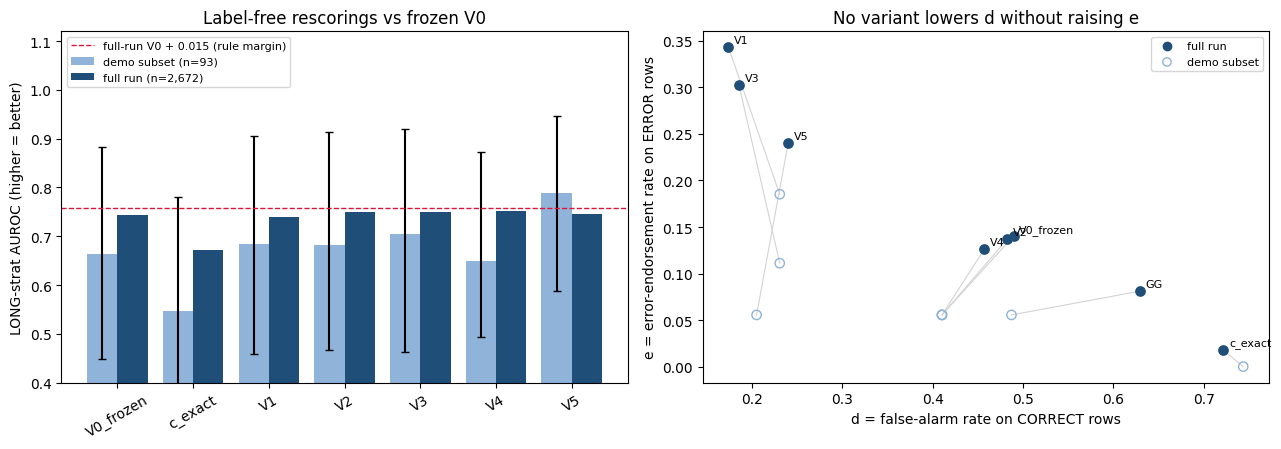

In [17]:
REF = data["metadata"]["reference_full_run"]
show = ["V0_frozen", "c_exact", "V1", "V2", "V3", "V4", "V5"]
tab = []
for s in show:
    tab.append({"score": s,
                "LONG-strat demo": A["auroc"]["LONG-strat"][s]["auroc"], "LONG-strat full": REF["auroc"]["LONG-strat"][s],
                "ALL-strat demo": A["auroc"]["ALL-strat"][s]["auroc"], "ALL-strat full": REF["auroc"]["ALL-strat"][s],
                "Δ LONG vs V0 demo": A["auroc"]["LONG-strat"][s]["auroc"] - A["auroc"]["LONG-strat"]["V0_frozen"]["auroc"],
                "Δ LONG vs V0 full": REF["auroc"]["LONG-strat"][s] - REF["auroc"]["LONG-strat"]["V0_frozen"],
                "e demo": A["ed"]["ALL"][s]["e"], "e full": REF["ed_ALL"][s]["e"],
                "d demo": A["ed"]["ALL"][s]["d"], "d full": REF["ed_ALL"][s]["d"]})
tab = pd.DataFrame(tab)
print(tab.round(3).to_string(index=False))
print(f"\nDecision (demo subset, n={len(P)}): {winner}   | stability: {stab}   | null any-qualifies: {null['share_any_variant_qualifies']:.3f}")
print(f"Decision (full run, n=2672):       {REF['winner']}   | stability: {REF['stability']['share_selected']}   | null any-qualifies: {REF['permutation_null']['share_any_variant_qualifies']}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
x = np.arange(len(show))
lo = [A["auroc"]["LONG-strat"][s]["ci"][0] for s in show]
hi = [A["auroc"]["LONG-strat"][s]["ci"][1] for s in show]
dm = [A["auroc"]["LONG-strat"][s]["auroc"] for s in show]
ax[0].bar(x - 0.2, dm, 0.4, label=f"demo subset (n={len(P)})", color="#8fb3d9",
          yerr=[np.array(dm) - np.array(lo, float), np.array(hi, float) - np.array(dm)], capsize=3)
ax[0].bar(x + 0.2, [REF["auroc"]["LONG-strat"][s] for s in show], 0.4, label="full run (n=2,672)", color="#1f4e79")
ax[0].axhline(REF["auroc"]["LONG-strat"]["V0_frozen"] + 0.015, ls="--", c="crimson", lw=1, label="full-run V0 + 0.015 (rule margin)")
ax[0].set_xticks(x, show, rotation=30)
ax[0].set_ylim(0.4, 1.12)
ax[0].set_ylabel("LONG-strat AUROC (higher = better)")
ax[0].set_title("Label-free rescorings vs frozen V0")
ax[0].legend(fontsize=8, loc="upper left")
for s in show + ["GG"]:
    if s == "GG":
        dd, ee = ed_gg["d"], ed_gg["e"]
        fd, fe = 0.629, 0.081  # full-run GG (gg_dev.json, ALL rows)
    else:
        dd, ee = A["ed"]["ALL"][s]["d"], A["ed"]["ALL"][s]["e"]
        fd, fe = REF["ed_ALL"][s]["d"], REF["ed_ALL"][s]["e"]
    ax[1].scatter(fd, fe, c="#1f4e79", s=45)
    ax[1].scatter(dd, ee, facecolors="none", edgecolors="#8fb3d9", s=45)
    ax[1].plot([fd, dd], [fe, ee], c="lightgray", lw=0.8, zorder=0)
    ax[1].annotate(s, (fd, fe), fontsize=8, xytext=(4, 3), textcoords="offset points")
ax[1].scatter([], [], c="#1f4e79", label="full run")
ax[1].scatter([], [], facecolors="none", edgecolors="#8fb3d9", label="demo subset")
ax[1].set_xlabel("d = false-alarm rate on CORRECT rows")
ax[1].set_ylabel("e = error-endorsement rate on ERROR rows")
ax[1].set_title("No variant lowers d without raising e")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Reading the results

* **The scoring reproduces exactly.** Recomputing V0_rep, c_exact and V1–V5 from the pairwise matrix gives the sealed
  full-run scores to machine precision, and V0_rep equals frozen V0 (gate G1). All of these scores are label-free.
* **The e/d trade-off also shows on the subset.** Plurality normalisation (V1, V3, V5) lowers the false-alarm rate `d`
  but raises error endorsement `e`, or leaves it unchanged. `c_exact` (no aligner) endorses almost nothing but flags most
  correct rows. GG has the lowest `e` in the full run but a higher `d`. That trade-off is why no variant cleanly fixes V0.
* **Do not read the demo's decision as a result.** With 12 sentences, one variant can clear the +0.015 margin by chance.
  The permutation null on the subset shows this directly: with random labels, some variant "qualifies" far more often than
  the full run's 3.5%. The pre-registered decision on the full development set is **"NONE: V0 stands"**, and all E
  numbers are development numbers.